# Phishing Email Detection — Complete ML Pipeline
**Dataset:** COMBINED_ceas08_nigerian_nazario.csv
**Steps:** 1 → 14 | Base models: Random Forest · XGBoost · Logistic Regression · SVM | Ensemble: Soft Voting

## Setup — Install & Import

In [1]:
# Run once to install missing packages
import sys
!{sys.executable} -m pip install imbalanced-learn xgboost --quiet


'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os, re, csv, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve,
)
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings('ignore')
csv.field_size_limit(10_000_000)
print("All libraries imported successfully.")

All libraries imported successfully.


## Configuration

In [3]:

DATA_PATH      = r'C:\Users\wongh\OneDrive\Documents\fyp2 code\COMBINED_ceas08_nigerian_nazario.csv'
OUTPUT_DIR     = r'C:\Users\wongh\OneDrive\Documents\fyp2 code\output'
MODEL_DIR      = r'C:\Users\wongh\OneDrive\Documents\fyp2 code\models'
RANDOM_STATE   = 42
TEST_SIZE      = 0.20
TFIDF_FEATURES = 2000
SHAP_SAMPLES   = 500
TOP_N_FEATURES = 20

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

# ── Keyword lists ──────────────────────────────────────────────────────────────
URGENCY_WORDS = [
    'urgent', 'immediately', 'verify', 'update', 'confirm', 'suspend',
    'limited', 'expire', 'click here', 'act now', 'account', 'security',
    'password', 'login', 'bank', 'credit', 'prize', 'winner',
    'congratulation', 'free', 'offer', 'risk', 'warning', 'alert',
    'suspended', 'unauthorized', 'validate', 'required', 'access',
]
SPAM_WORDS = [
    'viagra', 'cialis', 'pharmacy', 'prescription', 'pills', 'medication',
    'casino', 'lottery', 'million', 'billion', 'inheritance', 'nigeria',
    'prince', 'transfer', 'wire', 'bitcoin', 'crypto', 'investment',
    'enlarge', 'sex', 'adult', 'dating', 'weight loss', 'diet', 'slim',
    'cash', 'income', 'make money', 'work from home', 'get rich', 'fast cash',
    'no cost', 'click below', 'unsubscribe', 'dear friend', 'dear beneficiary',
]
FREE_EMAIL_PROVIDERS = {
    'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com',
    'protonmail.com', 'icloud.com', 'mail.com', 'ymail.com', 'live.com',
    'msn.com', 'inbox.com', 'zoho.com', 'gmx.com', 'fastmail.com',
    'rediffmail.com', 'yandex.com', 'mail.ru',
}
print("Configuration set.")


Configuration set.


## Helper Functions

In [4]:
def safe_str(val):
    return str(val) if pd.notna(val) else ''

def count_keywords(text, word_list):
    text_lower = text.lower()
    return sum(1 for w in word_list if w in text_lower)

def count_html_tags(text):
    return len(re.findall(r'<[^>]{1,300}>', text))

def count_anchor_tags(text):
    return len(re.findall(r'<a[\s>]', text, re.IGNORECASE))

def extract_urls_from_text(text):
    return re.findall(r"https?://[^\s<>\"'{}|\\^`\[\]]+", text)

def has_ip_based_url(urls):
    ip_pat = re.compile(r'https?://\d{1,3}(?:\.\d{1,3}){3}')
    return int(any(ip_pat.match(u) for u in urls))

def has_suspicious_url(urls):
    markers = ['.tk', '.ml', '.ga', '.cf', '.gq', 'bit.ly', 'tinyurl',
               'goo.gl', 'ow.ly', 'shorturl', 't.co']
    return int(any(m in u.lower() for u in urls for m in markers))

def extract_domain(email_str):
    m = re.search(r'@([\w.\-]+)', safe_str(email_str))
    return m.group(1).lower() if m else 'unknown'

def parse_date(date_str):
    fmts = [
        '%a, %d %b %Y %H:%M:%S %z',
        '%a, %d %b %Y %H:%M:%S %Z',
        '%d %b %Y %H:%M:%S %z',
        '%a, %d %b %Y %H:%M:%S',
    ]
    for fmt in fmts:
        try:
            dt = datetime.strptime(date_str.strip(), fmt)
            return dt.hour, dt.weekday(), int(dt.weekday() >= 5)
        except (ValueError, AttributeError):
            continue
    return 12, 2, 0

print("Helper functions defined.")


Helper functions defined.


## Step 2 — Exploratory Data Analysis

In [5]:
df_raw = pd.read_csv(
    DATA_PATH, encoding='utf-8', encoding_errors='replace',
    on_bad_lines='skip', engine='python',
)

print(f"Dataset shape  : {df_raw.shape}")
print(f"Columns        : {list(df_raw.columns)}")
print(f"\nLabel distribution:")
print(df_raw['label'].value_counts())
print(f"\nMissing values per column:")
print(df_raw.isnull().sum())
print(f"\nDuplicate rows : {df_raw.duplicated().sum()}")


Dataset shape  : (44051, 7)
Columns        : ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Label distribution:
label
1    24414
0    19637
Name: count, dtype: int64

Missing values per column:
sender       331
receiver    1882
date         483
subject       71
body           0
label          0
urls           0
dtype: int64

Duplicate rows : 0


In [6]:
# Dataset table preview - truncated text + label
_preview = df_raw[['body','label']].head().copy()
_preview['text'] = _preview['body'].str.slice(0, 60) + '...'
display(_preview[['text', 'label']])


,text,label
0,"Buck up, your troubles caused by small dimensi...",1
1,\nUpgrade your sex and pleasures with these te...,1
2,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1
3,Would anyone object to removing .so from this ...,0
4,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1


In [7]:
# Dataset preview — first 5 rows
print("=== Dataset Preview (first 5 rows) ===")
preview_cols = ['sender', 'receiver', 'date', 'subject', 'label', 'urls']
display(df_raw[preview_cols].head())

print("\n=== Sample Email Bodies ===")
for label, name in [(1, 'Spam'), (0, 'Ham')]:
    sample = df_raw[df_raw['label'] == label]['body'].dropna().iloc[0]
    print(f"\n[{name}] Body preview (first 300 chars):")
    print(sample[:300])
    print("...")


=== Dataset Preview (first 5 rows) ===


,sender,receiver,date,subject,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,1,1



=== Sample Email Bodies ===

[Spam] Body preview (first 300 chars):
Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.
...

[Ham] Body preview (first 300 chars):
Would anyone object to removing .so from this list?  The .so TLD is  
basically dead and we've found that lots of bogus domains like lib*.so  
are being caught by this.  Also sometimes you'll have spammers who are  
putting in gibberish or funny punctuation and you'll get sentences  
like 'blah blah
...


In [8]:
# Body length statistics by class
body_len = df_raw['body'].dropna().str.len()
print("Body length statistics:")
print(body_len.describe().round(0).to_string())
print(f"\nSample spam email subject:")
print(df_raw[df_raw['label']==1]['subject'].dropna().iloc[0])
print(f"\nSample ham email subject:")
print(df_raw[df_raw['label']==0]['subject'].dropna().iloc[0])


Body length statistics:
count      44051.0
mean        1764.0
std        22715.0
min            1.0
25%          253.0
50%          634.0
75%         2016.0
max      4599644.0

Sample spam email subject:
Never agree to be a loser

Sample ham email subject:
Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm t/uri_text.t


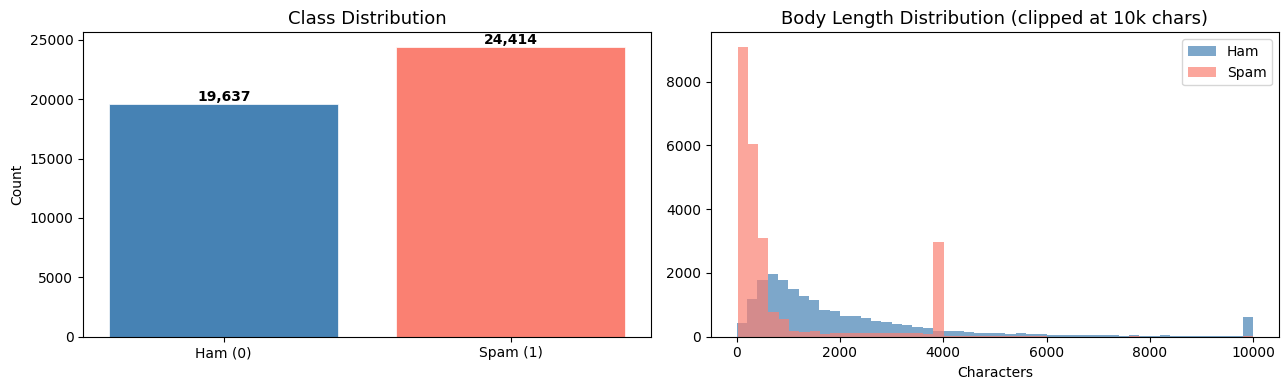

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df_raw['label'].value_counts().sort_index()
bars = axes[0].bar(['Ham (0)', 'Spam (1)'], counts.values,
                   color=['steelblue', 'salmon'], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')

# Body length distribution
body_lengths = df_raw['body'].dropna().str.len().clip(upper=10_000)
ham_idx  = df_raw.loc[body_lengths.index, 'label'] == 0
spam_idx = df_raw.loc[body_lengths.index, 'label'] == 1
axes[1].hist(body_lengths[ham_idx],  bins=50, alpha=0.7, color='steelblue', label='Ham')
axes[1].hist(body_lengths[spam_idx], bins=50, alpha=0.7, color='salmon',    label='Spam')
axes[1].set_title('Body Length Distribution (clipped at 10k chars)', fontsize=13)
axes[1].set_xlabel('Characters')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_eda.png'), dpi=150)
plt.show()


## Step 3 — Data Cleaning

In [10]:
df = df_raw.copy()

before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed duplicates        : {before - len(df):>5}  →  {len(df):,} rows")

before = len(df)
df.dropna(subset=['label', 'body'], inplace=True)
print(f"Removed null label/body   : {before - len(df):>5}  →  {len(df):,} rows")

before = len(df)
df = df[df['body'].str.strip().str.len() > 0]
print(f"Removed empty body rows   : {before - len(df):>5}  →  {len(df):,} rows")

df['subject']  = df['subject'].fillna('').astype(str)
df['sender']   = df['sender'].fillna('unknown@unknown.com').astype(str)
df['receiver'] = df['receiver'].fillna('').astype(str)
df['date']     = df['date'].fillna('').astype(str)
df['urls']     = pd.to_numeric(df['urls'], errors='coerce').fillna(0)
df['body']     = df['body'].astype(str)
df['label']    = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

print(f"\nFinal cleaned shape : {df.shape}")
print(f"Label distribution  :\n{df['label'].value_counts().to_string()}")


Removed duplicates        :     0  →  44,051 rows
Removed null label/body   :     0  →  44,051 rows
Removed empty body rows   :     3  →  44,048 rows

Final cleaned shape : (44048, 7)
Label distribution  :
label
1    24414
0    19634


## Step 4 — Data Preprocessing

In [11]:
# Combine subject + body for TF-IDF
df['text_combined'] = df['subject'] + ' ' + df['body']

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(df['label'])

print(f"Label classes  : {le.classes_}  →  encoded as {np.unique(y)}")
print(f"Label counts   : {Counter(y)}")
print(f"text_combined sample:\n{df['text_combined'].iloc[0][:300]}...")


Label classes  : [0 1]  →  encoded as [0 1]
Label counts   : Counter({np.int64(1): 24414, np.int64(0): 19634})
text_combined sample:
Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same....


## Step 6 — Feature Extraction

### Step 6.1 — Textual Features

In [12]:
def extract_textual(row):
    body    = safe_str(row['body'])
    subject = safe_str(row['subject'])
    text    = body + ' ' + subject
    cap_cnt = sum(1 for c in body if c.isupper())
    return {
        'body_length'        : len(body),
        'subject_length'     : len(subject),
        'word_count'         : len(body.split()),
        'urgency_word_count' : count_keywords(text, URGENCY_WORDS),
        'spam_word_count'    : count_keywords(text, SPAM_WORDS),
        'exclamation_count'  : text.count('!'),
        'question_mark_count': text.count('?'),
        'capital_ratio'      : cap_cnt / max(len(body), 1),
    }

print("Textual feature extractor defined.")


Textual feature extractor defined.


### Step 6.2 — Structural & URL-based Features

In [13]:
def extract_url_structural(row):
    body     = safe_str(row['body'])
    urls     = extract_urls_from_text(body)
    url_lens = [len(u) for u in urls] if urls else [0]
    return {
        'html_tag_count'    : count_html_tags(body),
        'has_html'          : int(bool(re.search(r'<html|<body|<div|<p[\s>]|<br', body, re.I))),
        'anchor_count'      : count_anchor_tags(body),
        'url_count_body'    : len(urls),
        'url_count_col'     : int(row.get('urls', 0)),
        'has_ip_url'        : has_ip_based_url(urls),
        'has_suspicious_url': has_suspicious_url(urls),
        'max_url_length'    : max(url_lens),
        'special_char_count': len(re.findall(r'[!@#$%^&*(){}\[\]|\\<>~`]', body)),
    }

print("URL & structural feature extractor defined.")


URL & structural feature extractor defined.


### Step 6.3 — Header & Metadata Features

In [14]:
def extract_header(row):
    sender_domain   = extract_domain(row['sender'])
    receiver_domain = extract_domain(row['receiver'])
    hour, weekday, is_weekend = parse_date(safe_str(row['date']))
    return {
        'is_free_email'              : int(sender_domain in FREE_EMAIL_PROVIDERS),
        'sender_domain_length'       : len(sender_domain),
        'sender_has_numbers'         : int(bool(re.search(r'\d', sender_domain))),
        'hour_of_day'                : hour,
        'day_of_week'                : weekday,
        'is_weekend'                 : is_weekend,
        'sender_receiver_domain_match': int(
            sender_domain == receiver_domain and sender_domain != 'unknown'
        ),
    }

print("Header & metadata feature extractor defined.")


Header & metadata feature extractor defined.


### Step 6.4 — Hybrid Feature Integration

In [15]:
print("Extracting features for all rows — this may take ~1 minute...")

textual_df = df.apply(extract_textual,        axis=1, result_type='expand')
url_df     = df.apply(extract_url_structural, axis=1, result_type='expand')
header_df  = df.apply(extract_header,         axis=1, result_type='expand')

eng_feat_df       = pd.concat([textual_df, url_df, header_df], axis=1)
ENG_FEATURE_NAMES = list(eng_feat_df.columns)
X_eng             = eng_feat_df.values.astype(np.float32)

print(f"Engineered features ({len(ENG_FEATURE_NAMES)}): {ENG_FEATURE_NAMES}")
print(f"Engineered matrix shape : {X_eng.shape}")
eng_feat_df.describe().round(2)


Extracting features for all rows — this may take ~1 minute...
Engineered features (24): ['body_length', 'subject_length', 'word_count', 'urgency_word_count', 'spam_word_count', 'exclamation_count', 'question_mark_count', 'capital_ratio', 'html_tag_count', 'has_html', 'anchor_count', 'url_count_body', 'url_count_col', 'has_ip_url', 'has_suspicious_url', 'max_url_length', 'special_char_count', 'is_free_email', 'sender_domain_length', 'sender_has_numbers', 'hour_of_day', 'day_of_week', 'is_weekend', 'sender_receiver_domain_match']
Engineered matrix shape : (44048, 24)


,body_length,subject_length,word_count,urgency_word_count,spam_word_count,exclamation_count,question_mark_count,capital_ratio,html_tag_count,has_html,...,has_suspicious_url,max_url_length,special_char_count,is_free_email,sender_domain_length,sender_has_numbers,hour_of_day,day_of_week,is_weekend,sender_receiver_domain_match
count,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.0,...,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00,44048.00
mean,1764.48,37.69,222.66,1.10,0.63,0.96,2.11,0.06,0.37,0.0,...,0.08,33.91,26.81,0.09,12.58,0.05,11.85,2.57,0.02,0.05
std,22715.62,24.44,800.18,1.65,0.94,7.16,10.78,0.08,2.11,0.0,...,0.27,40.74,242.89,0.28,4.39,0.22,6.80,1.07,0.15,0.22
min,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,254.00,23.00,38.00,0.00,0.00,0.00,0.00,0.02,0.00,0.0,...,0.00,0.00,1.00,0.00,9.00,0.00,6.00,2.00,0.00,0.00
50%,634.00,34.00,95.00,0.00,0.00,0.00,0.00,0.04,0.00,0.0,...,0.00,23.00,5.00,0.00,12.00,0.00,12.00,3.00,0.00,0.00
75%,2016.25,49.00,293.00,2.00,1.00,1.00,2.00,0.07,0.00,0.0,...,0.00,54.00,17.00,0.00,15.00,0.00,18.00,3.00,0.00,0.00
max,4599644.00,2657.00,127119.00,27.00,12.00,396.00,1843.00,0.92,280.00,0.0,...,1.00,1217.00,45535.00,1.00,57.00,1.00,23.00,6.00,1.00,1.00


### Cleaned + Engineered Table Preview
Email content after cleaning + feature engineering (first 8 rows).

In [16]:
# Cleaned table preview - sender, subject raw/norm, model text, URLs
_n = 8
_clean = df[['sender', 'label', 'subject', 'body']].head(_n).copy()

# subject_raw = original cleaned subject; subject_norm = lowercased + whitespace-collapsed
_clean['subject_raw']  = _clean['subject']
_clean['subject_norm'] = _clean['subject'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# text_model = what actually feeds the model (subject + body), truncated for display
_clean['text_model'] = (_clean['subject'].fillna('') + ' ' + _clean['body'].fillna('')).str.slice(0, 60) + '...'

# Extract URLs from body and count them
_clean['urls']   = _clean['body'].apply(extract_urls_from_text)
_clean['n_urls'] = _clean['urls'].str.len()

_cols = ['sender', 'label', 'subject_raw', 'subject_norm', 'text_model', 'n_urls', 'urls']
display(_clean[_cols])


,sender,label,subject_raw,subject_norm,text_model,n_urls,urls
0,Young Esposito <Young@iworld.de>,1,Never agree to be a loser,never agree to be a loser,"Never agree to be a loser Buck up, your troubl...",1,[http://whitedone.com/]
1,Mok <ipline's1983@icable.ph>,1,Befriend Jenna Jameson,befriend jenna jameson,Befriend Jenna Jameson \nUpgrade your sex and ...,1,[http://www.brightmade.com]
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,1,CNN.com Daily Top 10,cnn.com daily top 10,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,24,[http://www.cnn.com/video/partners/email/index...
3,Michael Parker <ivqrnai@pobox.com>,0,Re: svn commit: r619753 - in /spamassassin/tru...,re: svn commit: r619753 - in /spamassassin/tru...,Re: svn commit: r619753 - in /spamassassin/tru...,467,[http://en.wikipedia.org/wiki/.so_%28domain_na...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,1,SpecialPricesPharmMoreinfo,specialpricespharmmoreinfo,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1,[http://7iwfna.blu.livefilestore.com/y1pXdX3kw...
5,Caroline Aragon <dwthaidomainnamesm@thaidomain...,1,From Caroline Aragon,from caroline aragon,From Caroline Aragon \n\n\n\n\nYo wu urS mo ou...,0,[]
6,Replica Watches <jhorton@thebakercompanies.com>,1,Replica Watches,replica watches,Replica Watches We have fake Swiss Men's and L...,0,[]
7,Daily Top 10 <acidirev_1972@tcwpg.com>,1,CNN.com Daily Top 10,cnn.com daily top 10,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,24,[http://www.cnn.com/video/partners/email/index...


## Step 7 — Dataset Splitting (80 / 20 Stratified)

In [17]:
idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
print(f"Train : {len(idx_train):,}  |  Test : {len(idx_test):,}")
print(f"Train label distribution : {Counter(y_train)}")
print(f"Test  label distribution : {Counter(y_test)}")

# Fit TF-IDF on training text only — prevents data leakage
X_text = df['text_combined'].values
print(f"\nFitting TF-IDF (max_features={TFIDF_FEATURES}, bigrams, sublinear_tf)...")

tfidf = TfidfVectorizer(
    max_features=TFIDF_FEATURES,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,
)
tfidf.fit(X_text[idx_train])
X_tfidf_train = tfidf.transform(X_text[idx_train])
X_tfidf_test  = tfidf.transform(X_text[idx_test])

X_eng_train = X_eng[idx_train]
X_eng_test  = X_eng[idx_test]

# Combine sparse TF-IDF + dense engineered features
X_train_sparse = hstack([X_tfidf_train, csr_matrix(X_eng_train)])
X_test_sparse  = hstack([X_tfidf_test,  csr_matrix(X_eng_test)])
print(f"\nCombined matrix (train) : {X_train_sparse.shape}")
print(f"Combined matrix (test)  : {X_test_sparse.shape}")


Train : 35,238  |  Test : 8,810
Train label distribution : Counter({np.int64(1): 19531, np.int64(0): 15707})
Test  label distribution : Counter({np.int64(1): 4883, np.int64(0): 3927})

Fitting TF-IDF (max_features=2000, bigrams, sublinear_tf)...

Combined matrix (train) : (35238, 2024)
Combined matrix (test)  : (8810, 2024)


## Step 5 — Handle Class Imbalance (SMOTE)

Before SMOTE: Counter({np.int64(1): 19531, np.int64(0): 15707})
Converting to dense float32 for SMOTE (may use ~300 MB RAM)...
After  SMOTE: Counter({np.int64(0): 19531, np.int64(1): 19531})
SMOTE training shape: (39062, 2024)


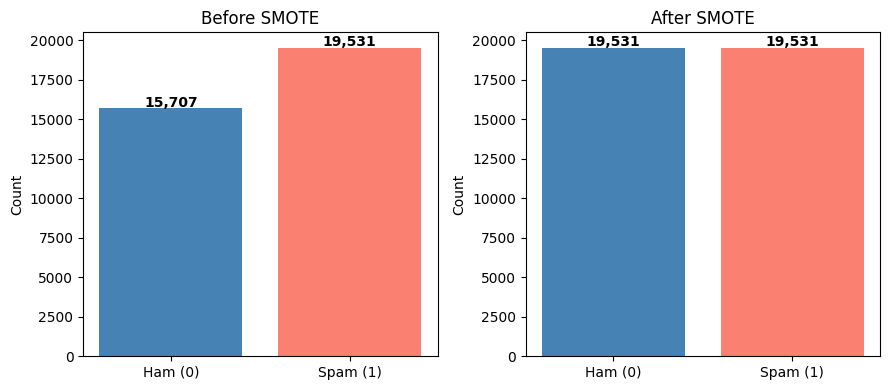

In [18]:
print(f"Before SMOTE: {Counter(y_train)}")
print("Converting to dense float32 for SMOTE (may use ~300 MB RAM)...")

X_train_dense = X_train_sparse.toarray().astype(np.float32)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_dense, y_train)

print(f"After  SMOTE: {Counter(y_train_smote)}")
print(f"SMOTE training shape: {X_train_smote.shape}")

X_test_dense = X_test_sparse.toarray().astype(np.float32)

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, counts, title in [
    (axes[0], Counter(y_train),       'Before SMOTE'),
    (axes[1], Counter(y_train_smote), 'After SMOTE'),
]:
    ax.bar(['Ham (0)', 'Spam (1)'], [counts[0], counts[1]],
           color=['steelblue', 'salmon'])
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_smote_balance.png'), dpi=150)
plt.show()


## Step 8 — Base Model Training

In [19]:
def train_and_eval(name, model, X_tr, y_tr, X_te, y_te):
    print(f"  Training {name}...")
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'name'     : name,
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall'   : recall_score(y_te, y_pred, zero_division=0),
        'f1'       : f1_score(y_te, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_te, y_proba),
    }


### Step 8.1 — Random Forest

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_leaf=1, n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_res = train_and_eval('Random Forest', rf_model,
                        X_train_smote, y_train_smote,
                        X_test_dense,  y_test)
print(f"  Done — F1: {rf_res['f1']:.4f}  ROC-AUC: {rf_res['roc_auc']:.4f}")


  Training Random Forest...
  Done — F1: 0.9886  ROC-AUC: 0.9990


### Step 8.2 — XGBoost

In [21]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_res = train_and_eval('XGBoost', xgb_model,
                          X_train_smote, y_train_smote,
                          X_test_dense,  y_test)
print(f"  Done — F1: {xgb_res['f1']:.4f}  ROC-AUC: {xgb_res['roc_auc']:.4f}")


  Training XGBoost...
  Done — F1: 0.9887  ROC-AUC: 0.9988


### Step 8.3 — Logistic Regression

In [22]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
])
lr_res = train_and_eval('Logistic Regression', lr_pipeline,
                         X_train_smote, y_train_smote,
                         X_test_dense,  y_test)
print(f"  Done — F1: {lr_res['f1']:.4f}  ROC-AUC: {lr_res['roc_auc']:.4f}")

  Training Logistic Regression...
  Done — F1: 0.9707  ROC-AUC: 0.9928


### Step 8.4 — Support Vector Machine (LinearSVC + Calibration)

In [23]:
# LinearSVC is fast on large datasets; CalibratedClassifierCV wraps it
# to provide predict_proba (required for soft-voting ensemble).
# StandardScaler(with_mean=False) keeps sparse compatibility.
svm_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('svm',    CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, max_iter=2000, dual='auto', random_state=RANDOM_STATE),
        cv=3,
    )),
])
svm_res = train_and_eval('SVM', svm_pipeline,
                         X_train_smote, y_train_smote,
                         X_test_dense,  y_test)
print(f"  Done — F1: {svm_res['f1']:.4f}  ROC-AUC: {svm_res['roc_auc']:.4f}")


  Training SVM...
  Done — F1: 0.9660  ROC-AUC: 0.9915


In [24]:
ALL_RESULTS = [rf_res, xgb_res, lr_res, svm_res]
print("All base models trained.")

All base models trained.


## Step 9 — Individual Model Evaluation

In [25]:
for res in ALL_RESULTS:
    print(f"\n{'─'*50}")
    print(f"  {res['name']}")
    print(f"  Accuracy  : {res['accuracy']:.4f}")
    print(f"  Precision : {res['precision']:.4f}")
    print(f"  Recall    : {res['recall']:.4f}")
    print(f"  F1-Score  : {res['f1']:.4f}")
    print(f"  ROC-AUC   : {res['roc_auc']:.4f}")
    print(f"\n{classification_report(y_test, res['y_pred'], target_names=['Ham','Spam'], digits=4)}")



──────────────────────────────────────────────────
  Random Forest
  Accuracy  : 0.9874
  Precision : 0.9907
  Recall    : 0.9865
  F1-Score  : 0.9886
  ROC-AUC   : 0.9990

              precision    recall  f1-score   support

         Ham     0.9833    0.9885    0.9859      3927
        Spam     0.9907    0.9865    0.9886      4883

    accuracy                         0.9874      8810
   macro avg     0.9870    0.9875    0.9873      8810
weighted avg     0.9874    0.9874    0.9874      8810


──────────────────────────────────────────────────
  XGBoost
  Accuracy  : 0.9875
  Precision : 0.9879
  Recall    : 0.9896
  F1-Score  : 0.9887
  ROC-AUC   : 0.9988

              precision    recall  f1-score   support

         Ham     0.9870    0.9850    0.9860      3927
        Spam     0.9879    0.9896    0.9887      4883

    accuracy                         0.9875      8810
   macro avg     0.9875    0.9873    0.9874      8810
weighted avg     0.9875    0.9875    0.9875      8810


───

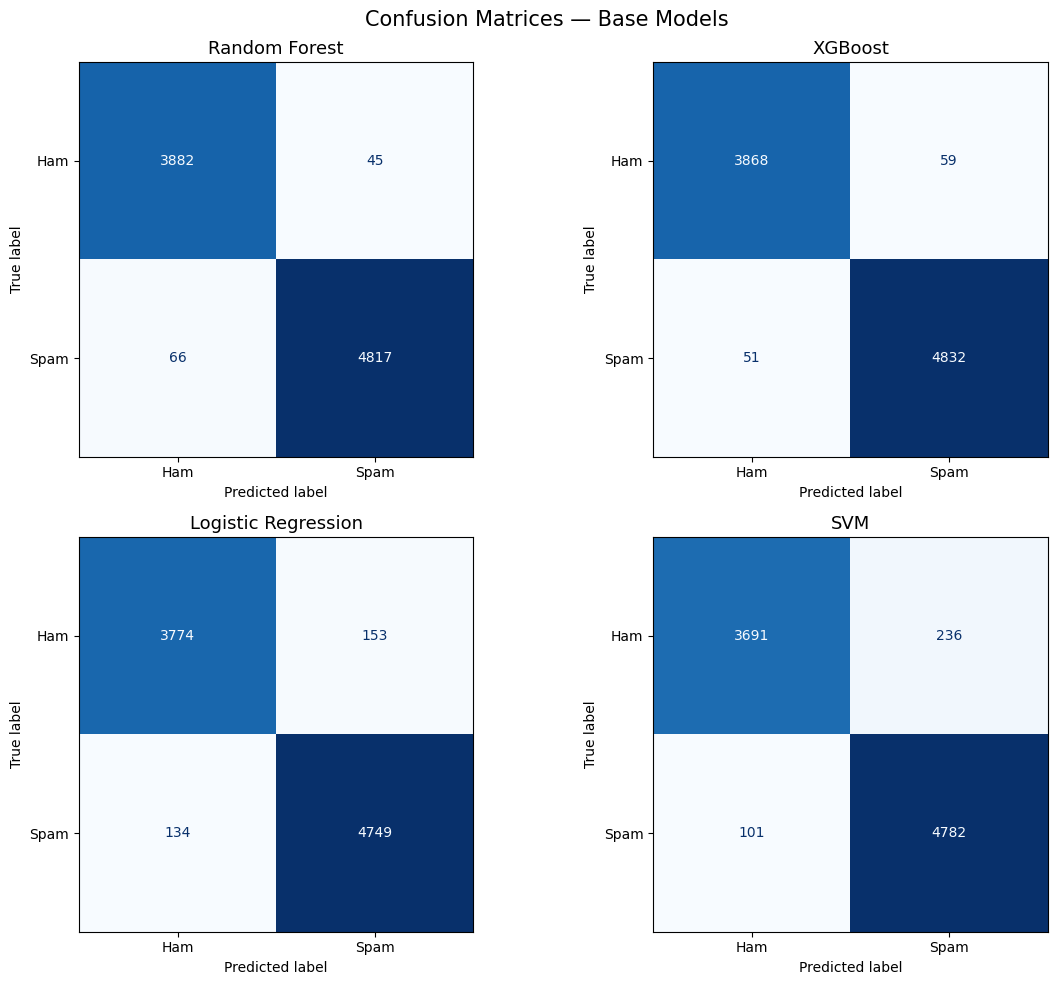

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, res in zip(axes.flatten(), ALL_RESULTS):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontsize=13)
plt.suptitle('Confusion Matrices — Base Models', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_confusion_matrices_base.png'), dpi=150)
plt.show()


## Step 10 — Soft Voting Ensemble

In [27]:
# Weighted soft voting: RF & XGBoost are the strongest base models (~0.99 F1),
# while LR & SVM are weaker (~0.97). Give the stronger models higher weight
# so the ensemble is not dragged down by the weaker learners.
proba_rf  = rf_res['y_proba']
proba_xgb = xgb_res['y_proba']
proba_lr  = lr_res['y_proba']
proba_svm = svm_res['y_proba']

w_rf, w_xgb, w_lr, w_svm = 2, 2, 1, 1
avg_proba = (w_rf*proba_rf + w_xgb*proba_xgb + w_lr*proba_lr + w_svm*proba_svm) / (w_rf + w_xgb + w_lr + w_svm)
ensemble_pred = (avg_proba >= 0.5).astype(int)

print(f"Weighted Soft Voting Ensemble: weights RF={w_rf}, XGB={w_xgb}, LR={w_lr}, SVM={w_svm}")
print(f"Ensemble prediction distribution: {Counter(ensemble_pred)}")


Weighted Soft Voting Ensemble: weights RF=2, XGB=2, LR=1, SVM=1
Ensemble prediction distribution: Counter({np.int64(1): 4887, np.int64(0): 3923})


## Step 11 — Ensemble Evaluation

In [28]:
ens_acc  = accuracy_score(y_test, ensemble_pred)
ens_pre  = precision_score(y_test, ensemble_pred, zero_division=0)
ens_rec  = recall_score(y_test, ensemble_pred, zero_division=0)
ens_f1   = f1_score(y_test, ensemble_pred, zero_division=0)
ens_auc  = roc_auc_score(y_test, avg_proba)

print(f"  Accuracy  : {ens_acc:.4f}")
print(f"  Precision : {ens_pre:.4f}")
print(f"  Recall    : {ens_rec:.4f}")
print(f"  F1-Score  : {ens_f1:.4f}")
print(f"  ROC-AUC   : {ens_auc:.4f}")
print(f"\n{classification_report(y_test, ensemble_pred, target_names=['Ham','Spam'], digits=4)}")


  Accuracy  : 0.9882
  Precision : 0.9890
  Recall    : 0.9898
  F1-Score  : 0.9894
  ROC-AUC   : 0.9990

              precision    recall  f1-score   support

         Ham     0.9873    0.9862    0.9868      3927
        Spam     0.9890    0.9898    0.9894      4883

    accuracy                         0.9882      8810
   macro avg     0.9881    0.9880    0.9881      8810
weighted avg     0.9882    0.9882    0.9882      8810



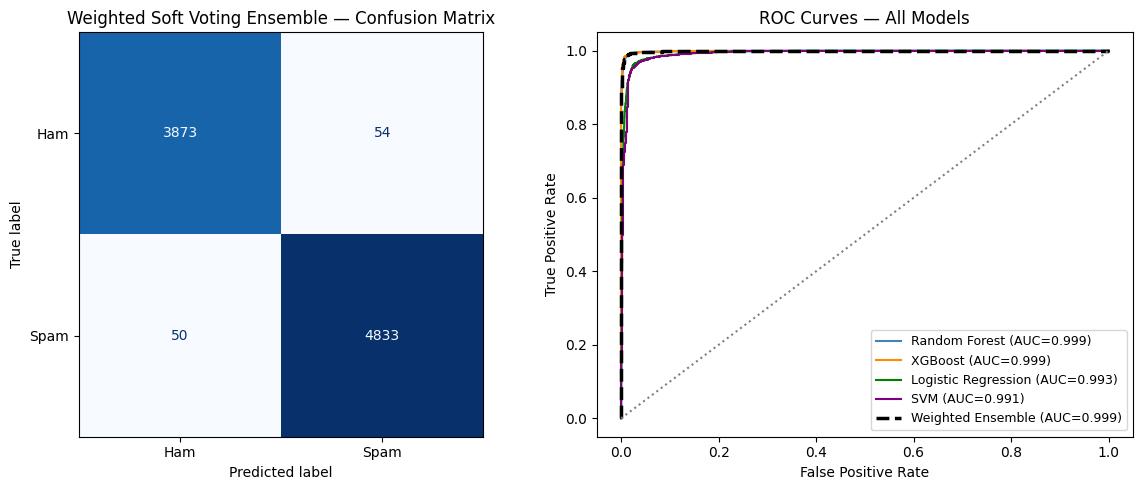

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, ensemble_pred),
                               display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Weighted Soft Voting Ensemble — Confusion Matrix', fontsize=12)

# ROC curves
colors = ['steelblue', 'darkorange', 'green', 'purple']
for res, c in zip(ALL_RESULTS, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1].plot(fpr, tpr, color=c, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
fpr_e, tpr_e, _ = roc_curve(y_test, avg_proba)
axes[1].plot(fpr_e, tpr_e, 'k--', lw=2.5, label=f"Weighted Ensemble (AUC={ens_auc:.3f})")
axes[1].plot([0,1],[0,1],'gray',linestyle=':')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontsize=12)
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_ensemble_roc.png'), dpi=150)
plt.show()


## Step 12 — Comparative Analysis

In [30]:
metric_keys = ('accuracy', 'precision', 'recall', 'f1', 'roc_auc')
rows = [{k: v for k, v in r.items() if k in ('name',) + metric_keys}
        for r in ALL_RESULTS]
rows.append({'name': 'Weighted Soft Voting Ensemble',
             'accuracy': ens_acc, 'precision': ens_pre,
             'recall': ens_rec, 'f1': ens_f1, 'roc_auc': ens_auc})

metrics_df = pd.DataFrame(rows).set_index('name')
metrics_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'metrics_comparison.csv'))
metrics_df.style.format('{:.4f}').highlight_max(color='lightgreen').highlight_min(color='#ffcccc')


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
name,,,,,
Random Forest,0.9874,0.9907,0.9865,0.9886,0.9990
XGBoost,0.9875,0.9879,0.9896,0.9887,0.9988
Logistic Regression,0.9674,0.9688,0.9726,0.9707,0.9928
SVM,0.9617,0.9530,0.9793,0.9660,0.9915
Weighted Soft Voting Ensemble,0.9882,0.9890,0.9898,0.9894,0.9990


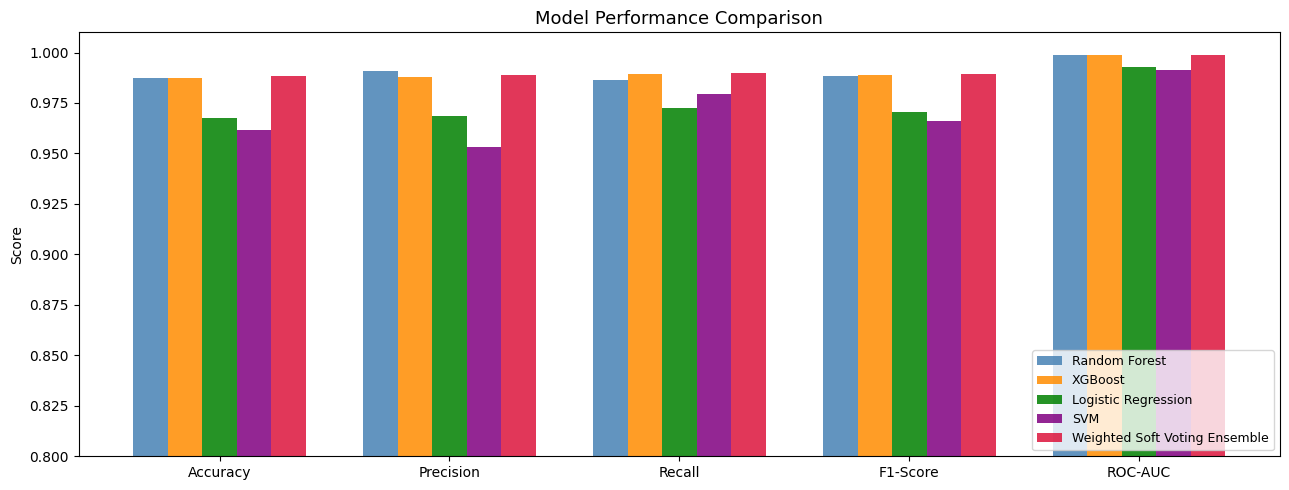

In [31]:
fig, ax = plt.subplots(figsize=(13, 5))
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(metric_labels))
width  = 0.15
colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson']
for i, (name, row_) in enumerate(metrics_df.iterrows()):
    ax.bar(x + i*width, row_.values, width, label=name, color=colors[i], alpha=0.85)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0.80, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_model_comparison.png'), dpi=150)
plt.show()


## Step 13 — Feature Importance Analysis
Use **Random Forest feature importance** (Gini impurity decrease) to identify the top contributing features.
Engineered features are highlighted in orange; TF-IDF terms in blue.

In [32]:
# Combined feature names: TF-IDF features first, then engineered features
feature_names = list(tfidf.get_feature_names_out()) + list(ENG_FEATURE_NAMES)
n_tfidf = len(tfidf.get_feature_names_out())
n_eng   = len(ENG_FEATURE_NAMES)
print(f"Total features : {len(feature_names):,}  (TF-IDF: {n_tfidf:,}  |  Engineered: {n_eng})")


Total features : 2,024  (TF-IDF: 2,000  |  Engineered: 24)


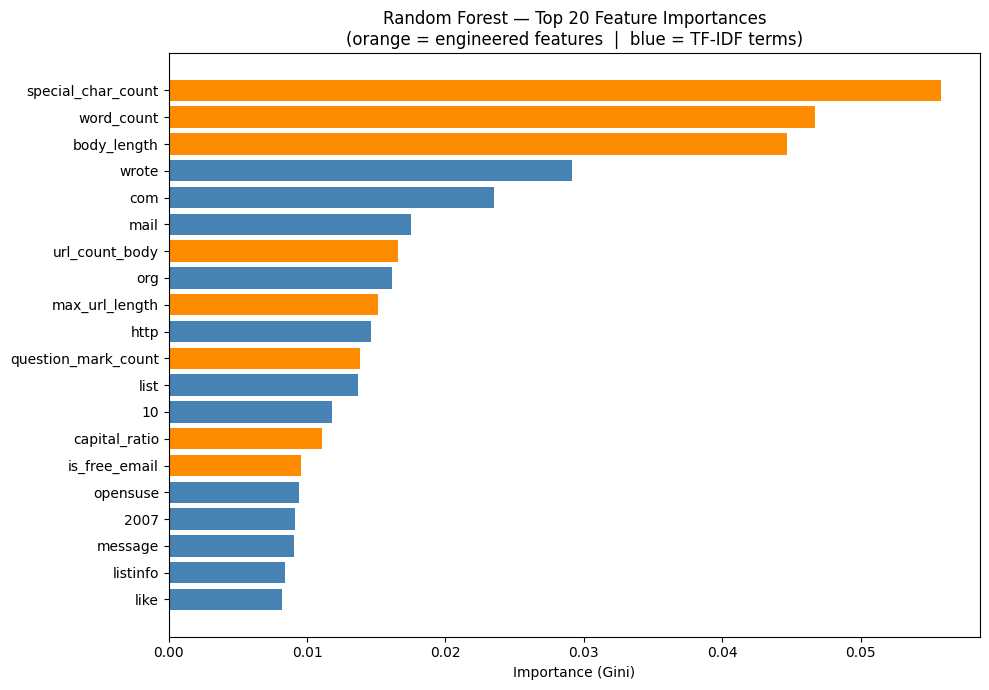

Top 15 features:


,feature,rf_importance
0,special_char_count,0.055836
1,word_count,0.046674
2,body_length,0.044708
3,wrote,0.029165
4,com,0.023471
5,mail,0.017502
6,url_count_body,0.016604
7,org,0.016164
8,max_url_length,0.015098
9,http,0.014635


Saved -> C:\Users\wongh\OneDrive\Documents\fyp2 code\output\feature_importance.csv


In [33]:
# ── Random Forest built-in feature importance ─────────────────────────────────
rf_importance = rf_model.feature_importances_
top_idx       = np.argsort(rf_importance)[-TOP_N_FEATURES:][::-1]
top_names     = [feature_names[i] for i in top_idx]
top_vals      = rf_importance[top_idx]

# Colour engineered features differently
colors_bar = ['darkorange' if n in ENG_FEATURE_NAMES else 'steelblue' for n in top_names]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_names[::-1], top_vals[::-1], color=colors_bar[::-1])
ax.set_title(
    f'Random Forest — Top {TOP_N_FEATURES} Feature Importances\n'
    '(orange = engineered features  |  blue = TF-IDF terms)',
    fontsize=12,
)
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save full ranking to CSV
fi_df = pd.DataFrame({'feature': feature_names, 'rf_importance': rf_importance})
fi_df.sort_values('rf_importance', ascending=False, inplace=True)
fi_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance.csv'), index=False)
print('Top 15 features:')
display(fi_df.head(15).reset_index(drop=True))
print(f"Saved -> {os.path.join(OUTPUT_DIR, 'feature_importance.csv')}")

## Step 14 — Save Trained Models

In [34]:
def save_pkl(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = os.path.getsize(path) / 1_048_576
    print(f"  Saved: {os.path.basename(path):40s} ({size_mb:.1f} MB)")


### Step 14.1 — Save Base Models

In [35]:
save_pkl(rf_model,     os.path.join(MODEL_DIR, 'model_rf.pkl'))
save_pkl(xgb_model,    os.path.join(MODEL_DIR, 'model_xgb.pkl'))
save_pkl(lr_pipeline,  os.path.join(MODEL_DIR, 'model_lr.pkl'))
save_pkl(svm_pipeline, os.path.join(MODEL_DIR, 'model_svm.pkl'))


  Saved: model_rf.pkl                             (66.4 MB)
  Saved: model_xgb.pkl                            (0.6 MB)
  Saved: model_lr.pkl                             (0.1 MB)
  Saved: model_svm.pkl                            (0.1 MB)


### Step 14.2 — Save Ensemble Model

In [36]:
ensemble_bundle = {
    'rf' : rf_model,
    'xgb': xgb_model,
    'lr' : lr_pipeline,
    'svm': svm_pipeline,
    'voting'     : 'weighted_soft_average',
    'weights'    : {'rf': 2, 'xgb': 2, 'lr': 1, 'svm': 1},
    'description': 'Weighted soft voting: weighted average of class-1 predict_proba (RF=2, XGB=2, LR=1, SVM=1)',
}
save_pkl(ensemble_bundle, os.path.join(MODEL_DIR, 'model_ensemble.pkl'))


  Saved: model_ensemble.pkl                       (67.2 MB)


### Step 14.3 — Save Feature Pipeline

In [37]:
feature_pipeline = {
    'tfidf'            : tfidf,
    'std_scaler'       : lr_pipeline.named_steps['scaler'],
    'svm_scaler'       : svm_pipeline.named_steps['scaler'],
    'label_encoder'    : le,
    'eng_feature_names': ENG_FEATURE_NAMES,
    'all_feature_names': list(tfidf.get_feature_names_out()) + list(ENG_FEATURE_NAMES),
    'tfidf_features'   : TFIDF_FEATURES,
}
save_pkl(feature_pipeline, os.path.join(MODEL_DIR, 'feature_pipeline.pkl'))

print()
print('All models and pipeline saved.')
print(f'  Models  -> {MODEL_DIR}')
print(f'  Plots   -> {OUTPUT_DIR}')

  Saved: feature_pipeline.pkl                     (0.2 MB)

All models and pipeline saved.
  Models  -> C:\Users\wongh\OneDrive\Documents\fyp2 code\models
  Plots   -> C:\Users\wongh\OneDrive\Documents\fyp2 code\output


## Final Summary

In [38]:
print("=" * 60)
print("  PIPELINE COMPLETE — RESULTS SUMMARY")
print("=" * 60)
display(metrics_df.style.format('{:.4f}').highlight_max(color='lightgreen'))


  PIPELINE COMPLETE — RESULTS SUMMARY


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
name,,,,,
Random Forest,0.9874,0.9907,0.9865,0.9886,0.9990
XGBoost,0.9875,0.9879,0.9896,0.9887,0.9988
Logistic Regression,0.9674,0.9688,0.9726,0.9707,0.9928
SVM,0.9617,0.9530,0.9793,0.9660,0.9915
Weighted Soft Voting Ensemble,0.9882,0.9890,0.9898,0.9894,0.9990
